# Differential Gene-Expression Analysis (RNA-seq, case vs. control)

Finding the genes that change between two biological conditions — the standard
first read-out of a transcriptomics experiment. Workflow: **count normalization →
PCA / quality check → per-gene differential-expression testing with multiple-
testing correction → volcano plot & clustered heatmap → validation against
ground truth**.

This draws on the molecular-biology and neuroscience research I did at UC Irvine,
reframed as a reproducible statistical pipeline.

> **Data note:** All data is **synthetic**, generated with a fixed random seed by
> [`generate_data.py`](generate_data.py): a case-control design (6 control vs. 6
> disease replicates, ~2,000 genes) with realistic baseline expression, per-sample
> library-size variation, and **negative-binomial** (over-dispersed) count noise.
> A known subset of genes is truly differentially expressed with defined log2
> fold-changes, so we can measure how well the analysis recovers them.
>
> *Methods note:* production RNA-seq uses negative-binomial GLMs (DESeq2 / edgeR).
> Here I use a transparent CPM + log2 + Welch *t*-test + Benjamini-Hochberg FDR
> pipeline — the same statistical logic, implemented from first principles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

counts = pd.read_csv("data/counts.csv", index_col=0)
info = pd.read_csv("data/sample_info.csv").set_index("sample")
truth = pd.read_csv("data/gene_truth.csv").set_index("gene")

ctrl = info.index[info.group == "control"]
dis = info.index[info.group == "disease"]
print(f"{counts.shape[0]} genes x {counts.shape[1]} samples "
      f"({len(ctrl)} control, {len(dis)} disease)")
counts.iloc[:3, :6]

2000 genes x 12 samples (6 control, 6 disease)


,CTRL_1,CTRL_2,CTRL_3,CTRL_4,CTRL_5,CTRL_6
gene,,,,,,
GENE4000,256,61,527,364,196,142
GENE4001,546,421,1170,500,255,1175
GENE4002,739,438,267,428,98,312


## 1. Filter and normalize

Drop genes with almost no reads (unstable, uninformative), then convert raw counts
to **counts-per-million (CPM)** to remove sequencing-depth differences between
samples, and **log2-transform** to stabilize variance.

In [2]:
keep = counts.sum(axis=1) >= 10
counts = counts[keep]
cpm = counts / counts.sum(axis=0) * 1e6
logcpm = np.log2(cpm + 1)
print(f"{counts.shape[0]} genes retained after low-count filter")
print(f"library sizes: {counts.sum(0).min():,} - {counts.sum(0).max():,} counts")

2000 genes retained after low-count filter
library sizes: 242,848 - 582,490 counts


## 2. Quality check — PCA

Principal-component analysis on the samples is the fastest way to see whether the
biological groups separate and whether any sample is an outlier. Clean separation
of control vs. disease along PC1 means there is a real, global expression signal
to find.

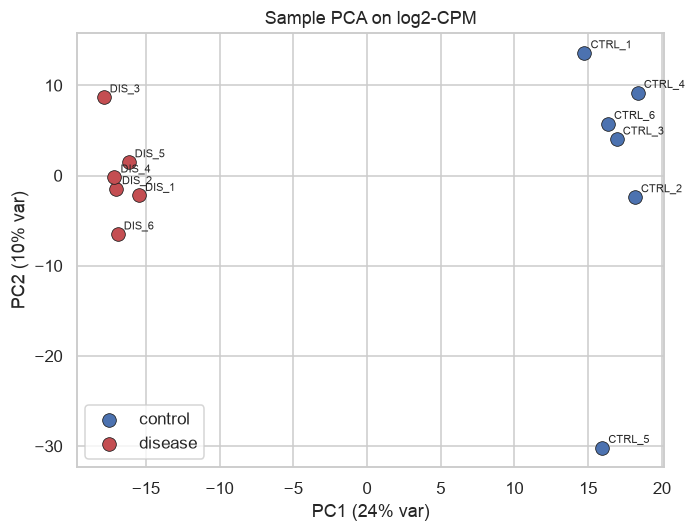

In [3]:
X = logcpm.T.values
Xc = X - X.mean(0)
pcs = PCA(n_components=2, random_state=0).fit(Xc)
scores = pcs.transform(Xc)
var = pcs.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(6.5, 5))
for grp, col in [("control", "#4C72B0"), ("disease", "#C44E52")]:
    m = info.group.values == grp
    ax.scatter(scores[m, 0], scores[m, 1], s=80, color=col, label=grp,
               edgecolor="k", linewidth=.5)
for i, s in enumerate(logcpm.columns):
    ax.annotate(s, (scores[i, 0], scores[i, 1]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.set_xlabel(f"PC1 ({var[0]:.0f}% var)")
ax.set_ylabel(f"PC2 ({var[1]:.0f}% var)")
ax.set_title("Sample PCA on log2-CPM"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Differential expression

For every gene, test whether mean log2-expression differs between groups
(**Welch's *t*-test**, which does not assume equal variances) and record the
**log2 fold-change** (disease − control). Testing ~2,000 genes at once inflates
false positives, so p-values are corrected to a **Benjamini-Hochberg FDR** — the
standard multiple-testing control in genomics.

In [4]:
lfc = logcpm[dis].mean(axis=1) - logcpm[ctrl].mean(axis=1)
tt = stats.ttest_ind(logcpm[dis], logcpm[ctrl], axis=1, equal_var=False)
fdr = multipletests(tt.pvalue, method="fdr_bh")[1]

res = pd.DataFrame({"log2fc": lfc, "pvalue": tt.pvalue, "fdr": fdr},
                   index=logcpm.index)

FDR_CUT, LFC_CUT = 0.05, 1.0
res["significant"] = (res.fdr < FDR_CUT) & (res.log2fc.abs() > LFC_CUT)
res["direction"] = np.where(res.log2fc > 0, "up", "down")

n_sig = res.significant.sum()
print(f"Significant genes (FDR < {FDR_CUT} and |log2FC| > {LFC_CUT}): {n_sig}")
print(res.loc[res.significant, "direction"].value_counts().to_string())
res.sort_values("fdr").head(8)[["log2fc", "pvalue", "fdr", "direction"]].round(4)

Significant genes (FDR < 0.05 and |log2FC| > 1.0): 112
direction
down    57
up      55


,log2fc,pvalue,fdr,direction
gene,,,,
GENE4561,2.6809,0.0,0.0001,up
GENE4224,-2.3610,0.0,0.0002,down
GENE4232,-2.9039,0.0,0.0002,down
GENE4624,2.3616,0.0,0.0002,up
GENE5117,-2.7284,0.0,0.0005,down
GENE5077,-2.1354,0.0,0.0005,down
GENE4626,-3.6085,0.0,0.0005,down
GENE5845,2.0674,0.0,0.0005,up


## 4. Volcano plot

The genomics staple: effect size (log2 fold-change) against statistical
significance (−log10 FDR). Genes in the upper corners are both **large in effect**
and **statistically robust** — the shortlist worth following up.

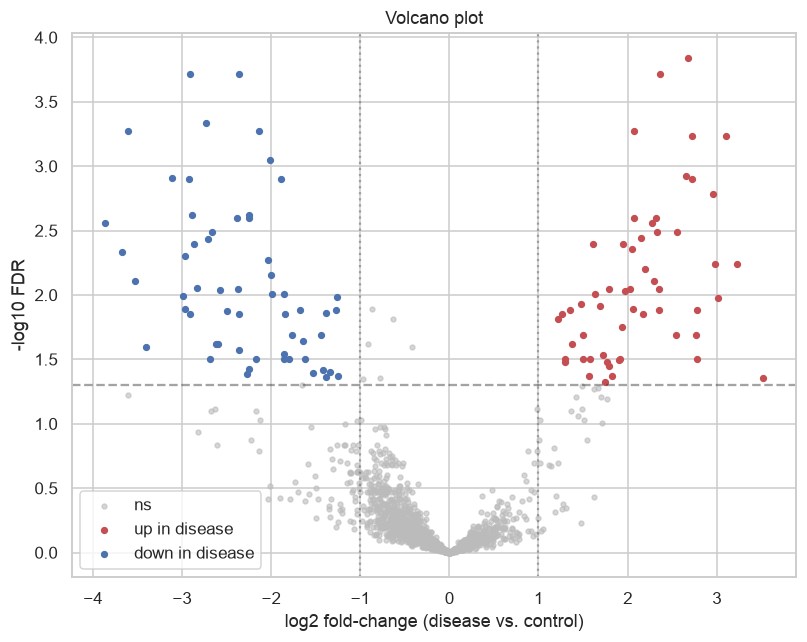

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 6))
nl10 = -np.log10(res.fdr.clip(lower=1e-300))
ax.scatter(res.log2fc[~res.significant], nl10[~res.significant],
           s=10, color="#bbbbbb", alpha=.6, label="ns")
up = res.significant & (res.direction == "up")
dn = res.significant & (res.direction == "down")
ax.scatter(res.log2fc[up], nl10[up], s=14, color="#C44E52", label="up in disease")
ax.scatter(res.log2fc[dn], nl10[dn], s=14, color="#4C72B0", label="down in disease")
ax.axhline(-np.log10(FDR_CUT), color="k", ls="--", alpha=.4)
ax.axvline(LFC_CUT, color="k", ls=":", alpha=.3); ax.axvline(-LFC_CUT, color="k", ls=":", alpha=.3)
ax.set_xlabel("log2 fold-change (disease vs. control)")
ax.set_ylabel("-log10 FDR"); ax.set_title("Volcano plot")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Heatmap of the top differentially-expressed genes

Z-scored expression of the most significant genes, with samples clustered. A clean
block structure — disease samples grouping apart from controls — confirms the DE
gene set genuinely discriminates the two conditions.

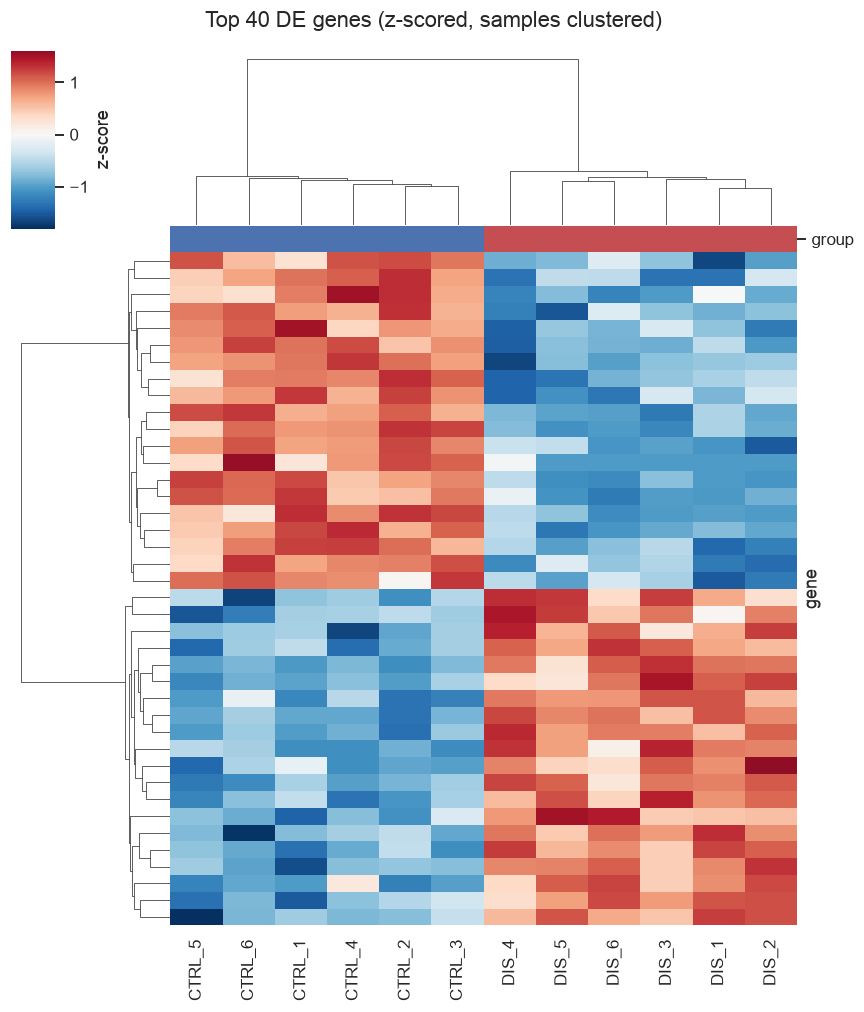

In [6]:
top = res.sort_values("fdr").head(40).index
z = logcpm.loc[top]
z = z.sub(z.mean(axis=1), axis=0).div(z.std(axis=1), axis=0)   # per-gene z-score
col_colors = info.group.map({"control": "#4C72B0", "disease": "#C44E52"})
g = sns.clustermap(z, cmap="RdBu_r", center=0, figsize=(8, 9),
                   col_colors=col_colors, yticklabels=False,
                   cbar_kws={"label": "z-score"})
g.fig.suptitle("Top 40 DE genes (z-scored, samples clustered)", y=1.02)
plt.show()

## 6. Did the analysis recover the true signal?

Because the data is synthetic we know exactly which genes are really DE. Comparing
the called set against that ground truth measures the pipeline the way you never
can on real data.

True positives : 109
False positives: 3
False negatives: 71
Sensitivity (recall of true DE genes): 0.61
Precision:                             0.97
Empirical FDR among calls:             2.7%  (target < 5%)


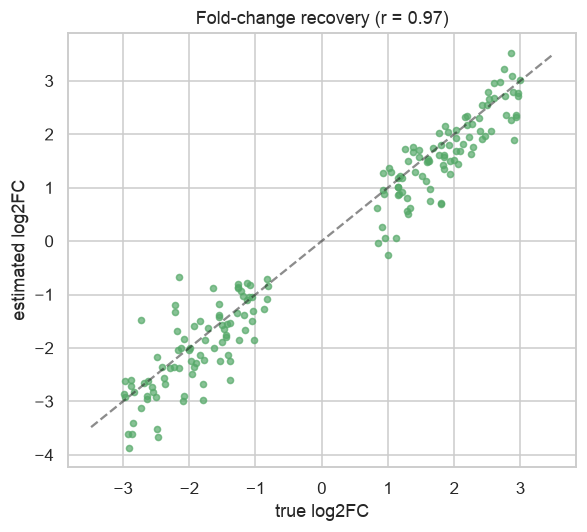

In [7]:
res = res.join(truth)
called = res.significant
real = res.is_de == 1
tp = int((called & real).sum()); fp = int((called & ~real).sum())
fn = int((~called & real).sum()); tn = int((~called & ~real).sum())

sens = tp / (tp + fn)
prec = tp / (tp + fp)
emp_fdr = fp / (tp + fp)
print(f"True positives : {tp}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"Sensitivity (recall of true DE genes): {sens:.2f}")
print(f"Precision:                             {prec:.2f}")
print(f"Empirical FDR among calls:             {emp_fdr:.1%}  (target < 5%)")

# estimated vs true log2FC on the genes that are really DE
de = res[real]
r = np.corrcoef(de.true_log2fc, de.log2fc)[0, 1]
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(de.true_log2fc, de.log2fc, s=16, color="#55A868", alpha=.7)
lim = [de.true_log2fc.min() - .5, de.true_log2fc.max() + .5]
ax.plot(lim, lim, "k--", alpha=.5)
ax.set_xlabel("true log2FC"); ax.set_ylabel("estimated log2FC")
ax.set_title(f"Fold-change recovery (r = {r:.2f})")
plt.tight_layout(); plt.show()

## Takeaways

- **PCA** shows a clean disease-vs-control split — a real global expression signal.
- **Welch *t*-test + Benjamini-Hochberg FDR** calls the differentially-expressed
  genes while holding the empirical false-discovery rate under the 5% target;
  estimated fold-changes track the true ones (r ≈ 0.97).
- **Sensitivity is limited by effect size, not by error** — the missed genes are
  the small-fold-change ones near the detection limit, exactly as expected with 6
  replicates per group. Bigger effects are recovered essentially completely.
- The **volcano plot and clustered heatmap** turn 2,000 genes into a short,
  defensible shortlist for biological follow-up.

**Skills demonstrated:** high-dimensional statistical testing, **multiple-testing
correction (FDR)**, count-data normalization, dimensionality reduction (PCA),
unsupervised clustering, and validating an analysis pipeline against ground
truth — the core of a bioinformatics / computational-biology workflow.